### **Bag of n_grams: Exercise**

- Fake news refers to misinformation or disinformation in the country which is spread through word of mouth and more recently through digital communication such as What's app messages, social media posts, etc.

- Fake news spreads faster than Real news and creates problems and fear among groups and in society.

- We are going to address these problems using classical NLP techniques and going to classify whether a given message/ text is **Real or Fake Message**.

- You will use a Bag of n-grams to pre-process the text and apply different classification algorithms.

- Sklearn CountVectorizer has the inbuilt implementations for Bag of Words.


### **About Data: Fake News Detection**

Credits: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset


- This data consists of two columns.
        - Text
        - label
- Text is the statements or messages regarding a particular event/situation.

- label feature tells whether the given Text is Fake or Real.

- As there are only 2 classes, this problem comes under the **Binary Classification.**


In [1]:
#import pandas library
import pandas as pd

#read the dataset with name "Fake_Real_Data.csv" and store it in a variable df
df=pd.read_csv("Fake_Real_Data.csv")



#print the shape of dataframe
print(df.shape)

#print top 5 rows
df.head()

(9900, 2)


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [2]:
#check the distribution of labels 
df.label.value_counts()


label
Fake    5000
Real    4900
Name: count, dtype: int64

In [4]:
#Add the new column "label_num" which gives a unique number to each of these labels 
df["label_num"]=df.label.map({"Real":0,"Fake":1})


#check the results with top 5 rows
df.head()


,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,1
1,U.S. conservative leader optimistic of common ...,Real,0
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,0
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,1
4,Democrats say Trump agrees to work on immigrat...,Real,0


In [5]:
df.drop("label",axis=1,inplace=True)
df.head()

,Text,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,1
1,U.S. conservative leader optimistic of common ...,0
2,"Trump proposes U.S. tax overhaul, stirs concer...",0
3,Court Forces Ohio To Allow Millions Of Illega...,1
4,Democrats say Trump agrees to work on immigrat...,0


### **Modelling without Pre-processing Text data**

In [7]:
#import train-test-split from sklearn 
from sklearn.model_selection import train_test_split

#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
X_train,X_test,y_train,y_test=train_test_split(df.Text,df.label_num,test_size=0.2,random_state=2022,stratify=df.label_num)



In [8]:
#print the shapes of X_train and X_test
print(X_train.shape)
print(X_test.shape)



(7920,)
(1980,)


**Attempt 1** :

1. using sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, bigram, and trigrams.
- use KNN as the classifier with n_neighbors of 10 and metric as 'euclidean' distance.
- print the classification report.


In [9]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(1,3))),
        ("classifier",KNN(n_neighbors=10,metric="euclidean"))
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.63      0.99      0.77       980
           1       0.98      0.42      0.59      1000

    accuracy                           0.70      1980
   macro avg       0.80      0.71      0.68      1980
weighted avg       0.80      0.70      0.68      1980



**Attempt 2** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, bigram, and trigrams.
- use **KNN** as the classifier with n_neighbors of 10 and metric as 'cosine' distance.
- print the classification report.


In [10]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(1,3))),
        ("classifier",KNN(n_neighbors=10,metric="cosine"))
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.65      1.00      0.79       980
           1       1.00      0.47      0.64      1000

    accuracy                           0.73      1980
   macro avg       0.83      0.74      0.72      1980
weighted avg       0.83      0.73      0.71      1980




**Attempt 3** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with only trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [11]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(1,3))),
        ("classifier",RandomForestClassifier())
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980




**Attempt 4** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with both unigram and bigrams.
- use **Multinomial Naive Bayes** as the classifier with an alpha value of 0.75.
- print the classification report.


In [12]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(1,3))),
        ("classifier",MultinomialNB(alpha=0.75))
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



<h3>Use text pre-processing to remove stop words, punctuations and apply lemmatization </h3>

In [13]:
#use this utility function to get the preprocessed text data

import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens) 

In [14]:
# create a new column "preprocessed_txt" and use the utility function above to get the clean data
# this will take some time, please be patient
df["preprocessed_txt"]=df.Text.apply(preprocess)
df.head()


,Text,label_num,preprocessed_txt
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,1,Trump surrogate BRUTALLY Stabs Pathetic VIDE...
1,U.S. conservative leader optimistic of common ...,0,U.S. conservative leader optimistic common gro...
2,"Trump proposes U.S. tax overhaul, stirs concer...",0,trump propose U.S. tax overhaul stir concern d...
3,Court Forces Ohio To Allow Millions Of Illega...,1,Court Forces Ohio allow Millions illegally p...
4,Democrats say Trump agrees to work on immigrat...,0,Democrats Trump agree work immigration bill wa...


In [15]:
#print the top 5 rows
df.tail()

,Text,label_num,preprocessed_txt
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,1,wikileak Admits screw IMMENSELY Twitter Poll...
9896,Trump consults Republican senators on Fed chie...,0,trump consult republican senator Fed chief can...
9897,Trump lawyers say judge lacks jurisdiction for...,0,trump lawyer judge lack jurisdiction defamatio...
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,1,WATCH right wing Pastor Falsely Credits Trum...
9899,Sean Spicer HILARIOUSLY Branded As Chickensh*...,1,Sean Spicer hilariously brand chickensh*t bo...


**Build a model with pre processed text**

In [16]:
#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
#Note: Make sure to use only the "preprocessed_txt" column for splitting
X_train,X_test,y_train,y_test=train_test_split(df.preprocessed_txt,df.label_num,test_size=0.2,random_state=2022,stratify=df.label_num)




**Let's check the scores with our best model till now**
- Random Forest

**Attempt1** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with only trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [17]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(3,3))),
        ("classifier",RandomForestClassifier())
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.98      0.92      0.95       980
           1       0.92      0.98      0.95      1000

    accuracy                           0.95      1980
   macro avg       0.95      0.95      0.95      1980
weighted avg       0.95      0.95      0.95      1980



**Attempt2** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, Bigram, and trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [18]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
clf=Pipeline(
    [
        ("vectorizer",CountVectorizer(ngram_range=(1,3))),
        ("classifier",RandomForestClassifier())
    ]
)



#2. fit with X_train and y_train
clf.fit(X_train,y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred=clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



<Axes: >

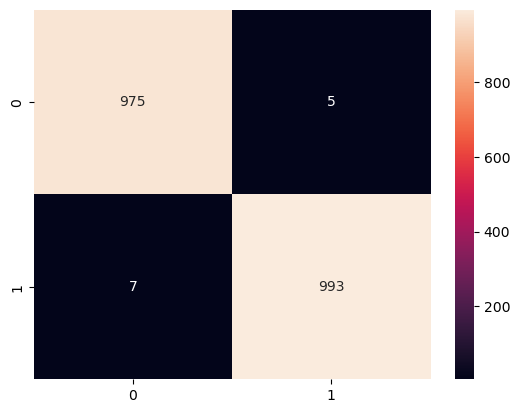

In [ ]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

## **Please write down Final Observations**


## [**Solution**](./bag_of_n_grams_exercise_solutions.ipynb)